In [1]:
!pip install pandas matplotlib seaborn plotly -U nbformat kaleido

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px



df = pd.read_csv(r"C:\Users\karth\apexplanet-data-analytics\data\Sample - Superstore_with_missing_and_duplicates.csv",encoding="cp1252")
print(df.head())
df["Order Date"] = pd.to_datetime(df["Order Date"])




   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Category  \
0     42420.0   Sout

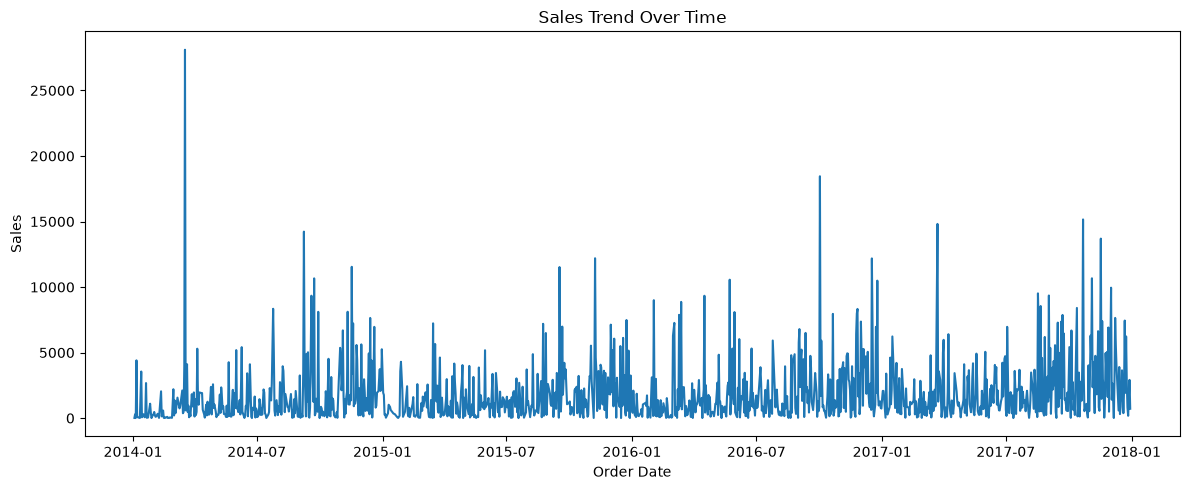

In [3]:
# 1. Line Chart – Sales Trend

sales_trend = df.groupby("Order Date")["Sales"].sum()

plt.figure(figsize=(12,5))
plt.plot(sales_trend)

plt.title("Sales Trend Over Time")
plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.tight_layout()
plt.savefig("line_chart.png", dpi=300)

plt.show()

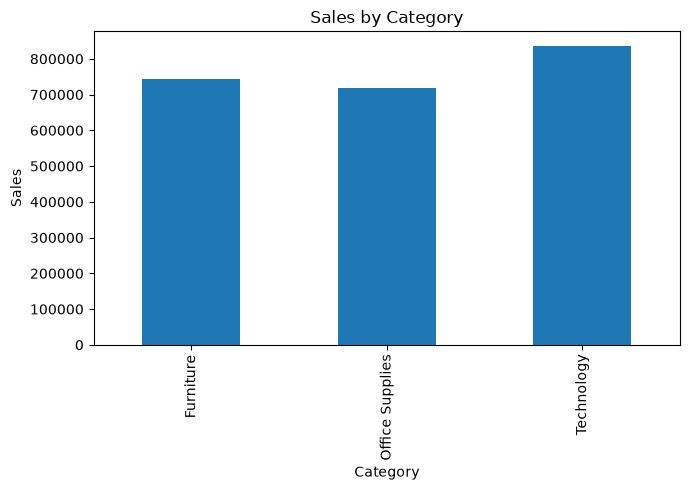

In [4]:
# 2. Bar Chart – Sales by Category

category_sales = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(7,5))
category_sales.plot(kind="bar")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.tight_layout()
plt.savefig("bar_chart.png", dpi=300)

plt.show()

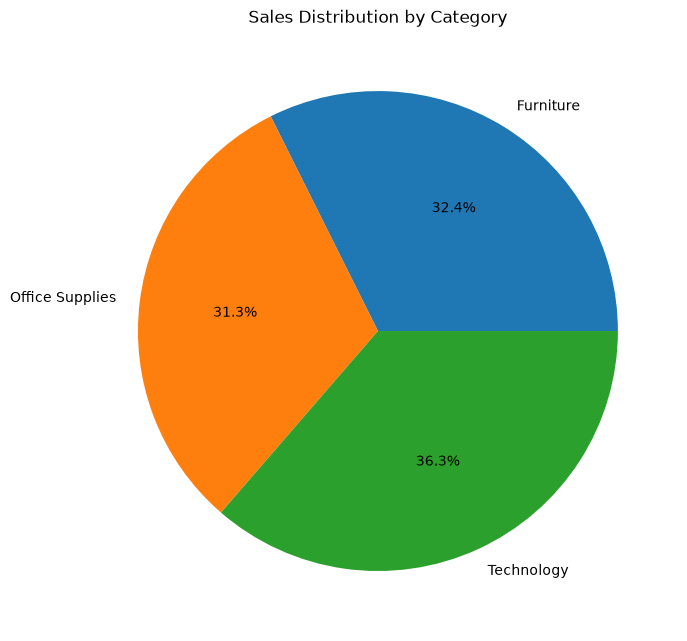

In [5]:
# 3. Pie Chart – Sales Distribution

plt.figure(figsize=(7,7))

category_sales.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Sales Distribution by Category")
plt.ylabel("")

plt.tight_layout()
plt.savefig("pie_chart.png", dpi=300)

plt.show()

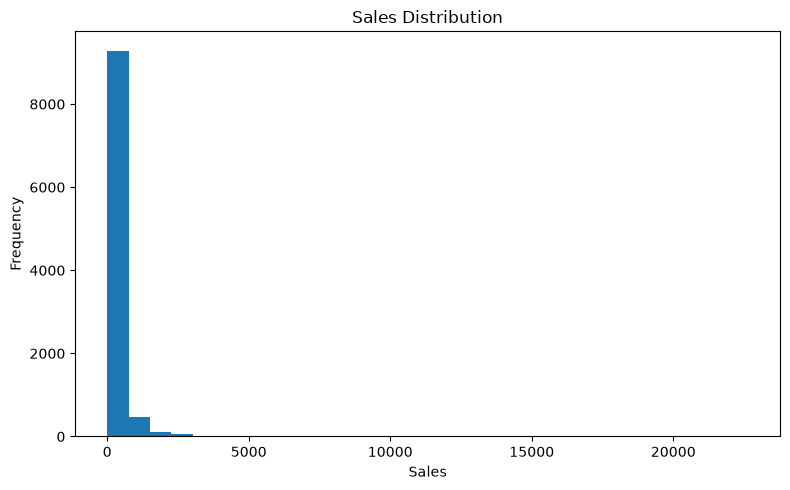

In [6]:
# 4. Histogram – Sales Distribution

plt.figure(figsize=(8,5))

plt.hist(df["Sales"], bins=30)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("histogram.png", dpi=300)

plt.show()

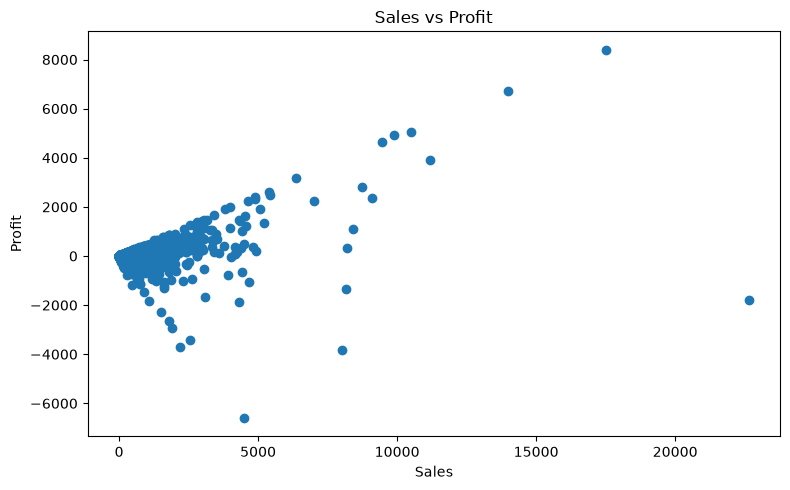

In [7]:
# 5. Scatter Plot – Sales vs Profit

plt.figure(figsize=(8,5))

plt.scatter(df["Sales"], df["Profit"])

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()
plt.savefig("scatter_plot.png", dpi=300)

plt.show()

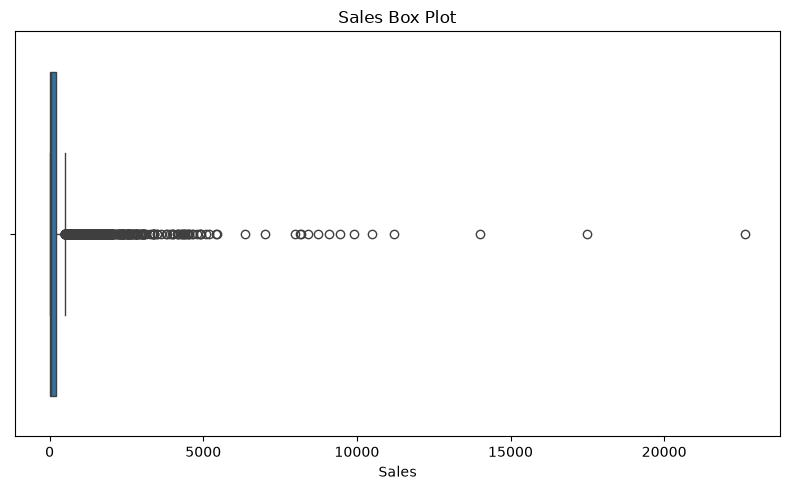

In [8]:
# 6. Box Plot – Sales

plt.figure(figsize=(8,5))

sns.boxplot(x=df["Sales"])

plt.title("Sales Box Plot")

plt.tight_layout()
plt.savefig("box_plot.png", dpi=300)

plt.show()

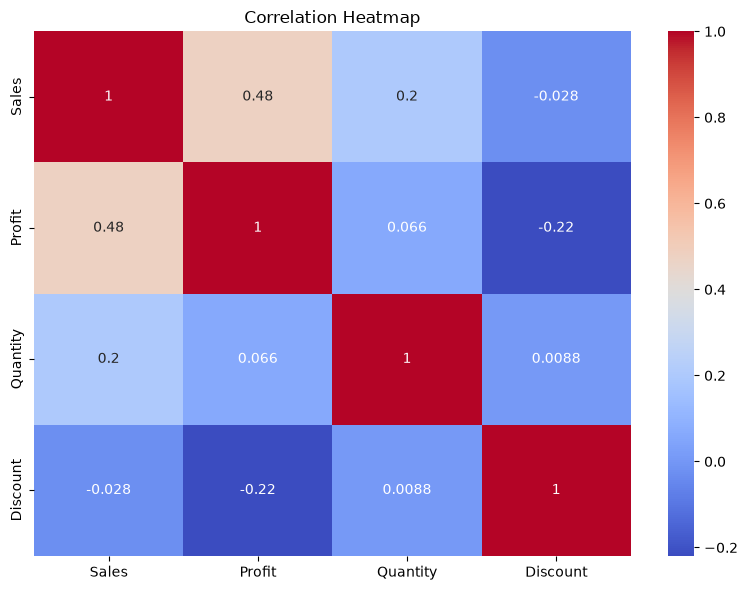

In [9]:
# 7. Heatmap – Correlation

numeric = df[["Sales","Profit","Quantity","Discount"]]

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.savefig("heatmap.png", dpi=300)

plt.show()

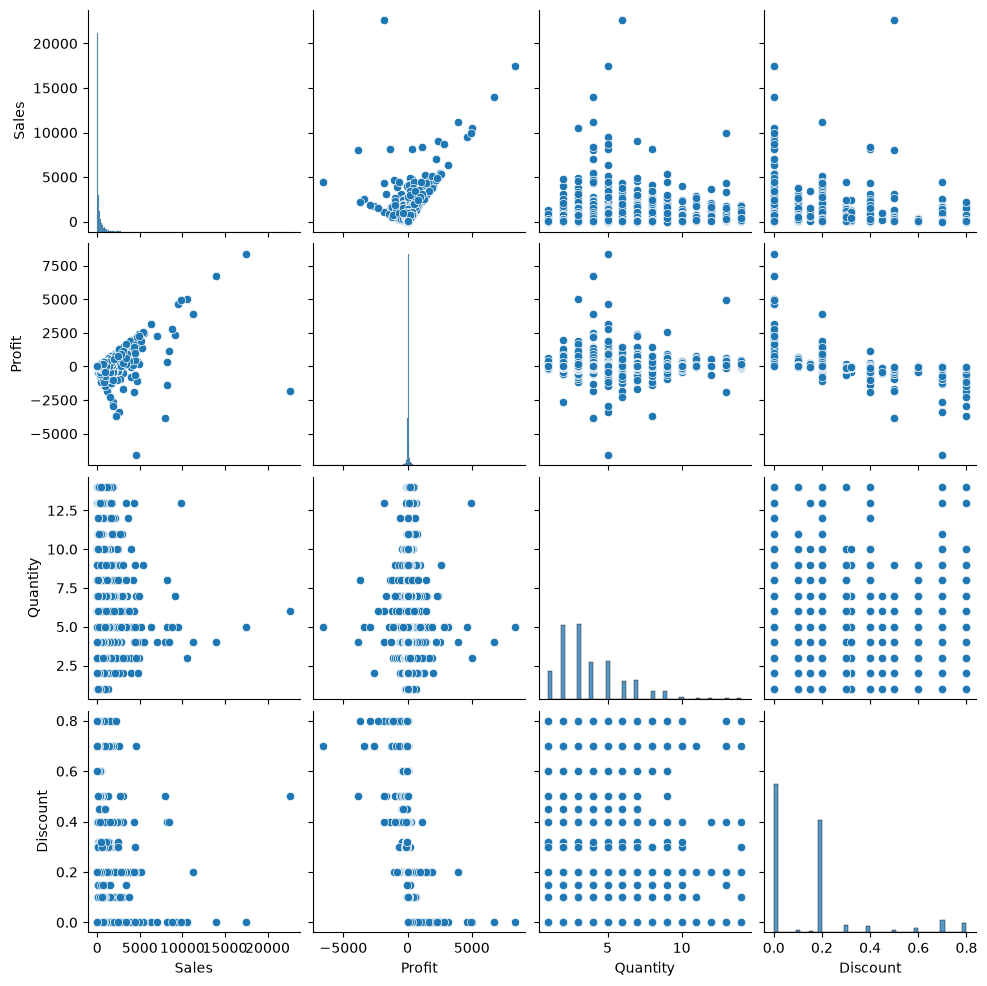

In [10]:
# 8. Pair Plot
pair = sns.pairplot(
    df[["Sales","Profit","Quantity","Discount"]]
)

pair.savefig("pairplot.png", dpi=300)

plt.show()

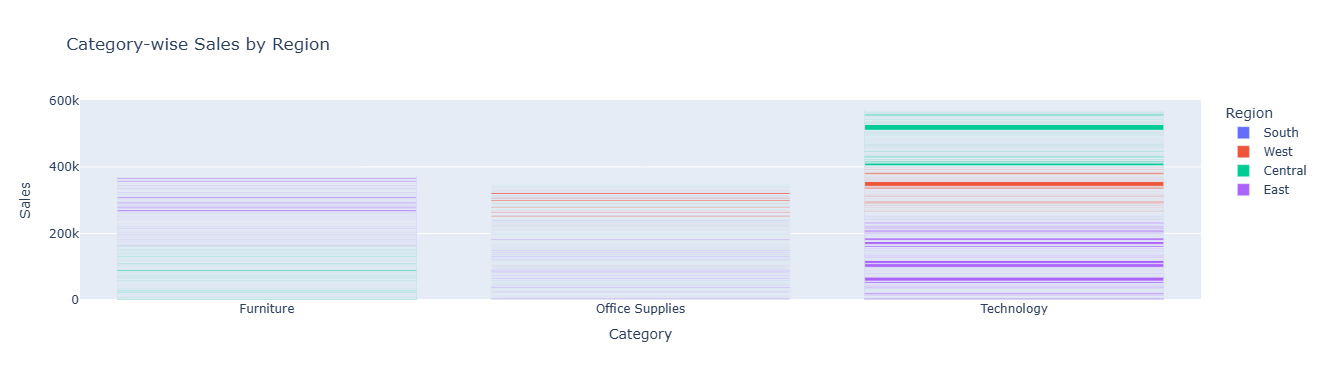

In [11]:
# 9. Plotly Interactive Bar Chart

fig = px.bar(
    df,
    x="Category",
    y="Sales",
    color="Region",
    title="Category-wise Sales by Region"
)

fig.write_image("interactive_bar_chart.png")

fig.show()